In [1]:
import statprep as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as spc

In [2]:
model_file = '/home/hereinlies/Documents/GlobusSharing/model.csv'
gmm_data = sp.gmm_setup(model_file)

In [3]:
gmm_data.to_csv('/home/hereinlies/Documents/GlobusSharing/gmm_data.csv',index=False)

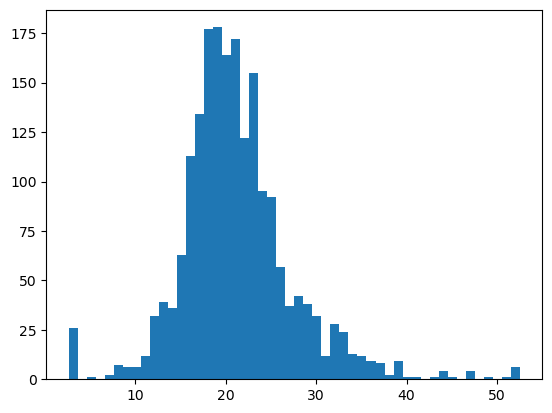

In [8]:
plt.hist(gmm_data["sum_entropy_parent"], bins='auto')  # arguments are passed to np.histogram
plt.show()

### Basic statistics (min 2 mo difference)

In [7]:
nn = len(list(set(gmm_data['name'])))
print(f'Number of children: {nn}')

Number of children: 404


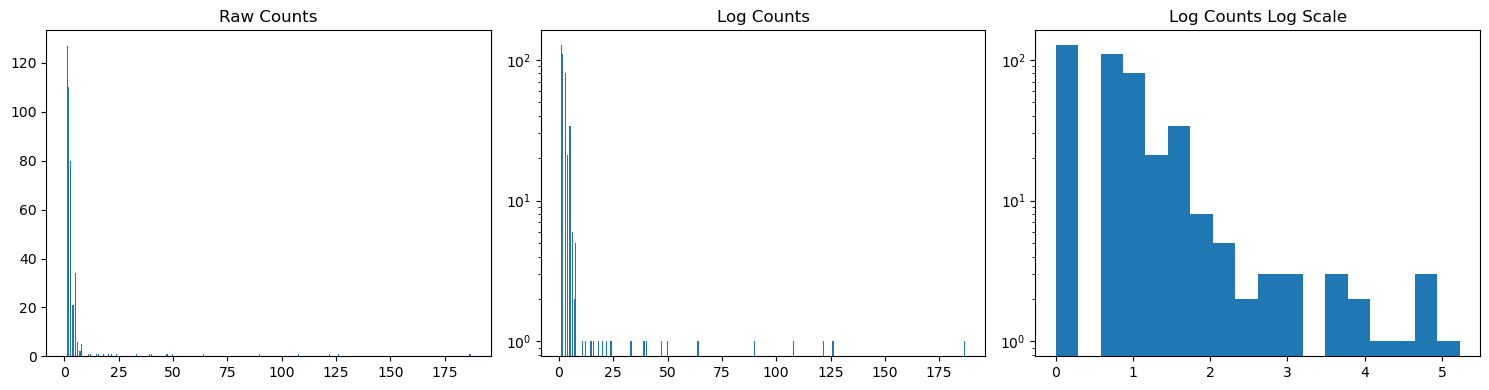

In [38]:
vc = gmm_data['name'].value_counts()
lvc = np.log(vc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(vc, bins='auto')
axes[0].set_title('Raw Counts')

axes[1].hist(vc, bins='auto',log=True)
axes[1].set_title('Log Counts')

axes[2].hist(lvc, bins='auto',log=True)
axes[2].set_title('Log Counts Log Scale')

plt.tight_layout()
plt.show()

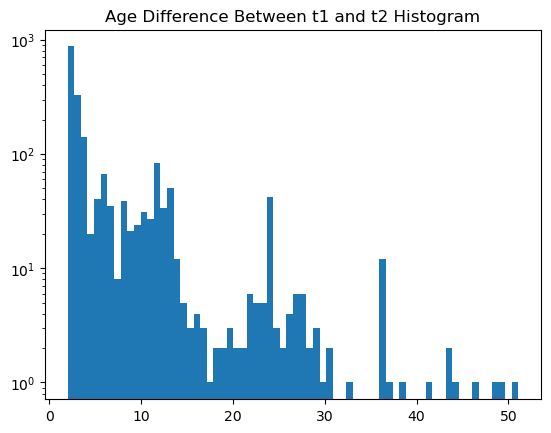

Verified, it it is mainly children who skipped meetings with the researcher


In [38]:
plt.hist(gmm_data["age_diff"], bins='auto',log=True)
plt.title('Age Difference Between t1 and t2 Histogram')
plt.show()
print("Verified, it it is mainly children who skipped meetings with the researcher")

### Basic statistics (no min)

In [5]:
gmm_data2 = sp.gmm_setup(model_file,min_age_gap=0)

##### code for lag correlation

In [29]:
BIN_WIDTH = 0.1          # width of gap bins, in same units as your gap column
MIN_PAIRS=10 # skip bins with too few pairs

# ---------------------------------------------------------------------------
# Bin the pairs and compute correlation per bin
# ---------------------------------------------------------------------------
def binned_lag_correlation(pairs, bin_width, max_gap=None, min_pairs=10):
    if max_gap is None:
        max_gap = pairs["age_diff"].max()

    bin_edges = np.arange(0, max_gap + bin_width, bin_width)
    pairs = pairs.copy()
    pairs["bin"] = pd.cut(pairs["age_diff"], bins=bin_edges, right=False)

    results = []
    for bin_label, bin_df in pairs.groupby("bin", observed=True):
        n_pairs = len(bin_df)
        if n_pairs < min_pairs:
            continue

        r = np.corrcoef(bin_df["sum_entropy_parent"], bin_df["sum_entropy_child"])[0,1]

        results.append({
            "bin": bin_label,
            "bin_mid": bin_label.mid,
            "r": r,
            "n_pairs": n_pairs,
        })

    return pd.DataFrame(results).sort_values("bin_mid").reset_index(drop=True)


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
def plot_lag_correlation(res, var1_name="var1", var2_name="var2", time_unit="units"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(res["bin_mid"], res["r"], marker="o", color="steelblue")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"Time gap ({time_unit})")
    ax.set_ylabel(f"Correlation ({var1_name} vs {var2_name})")
    ax.set_title("Correlation as a function of time gap")

    for _, row in res.iterrows():
        ax.annotate(f"n={row['n_pairs']}", (row["bin_mid"], row["r"]),
                     textcoords="offset points", xytext=(0, 8), fontsize=7, color="gray", ha="center")

    fig.tight_layout()
    return fig


res = binned_lag_correlation(gmm_data2, bin_width=BIN_WIDTH)



##### running croos cor

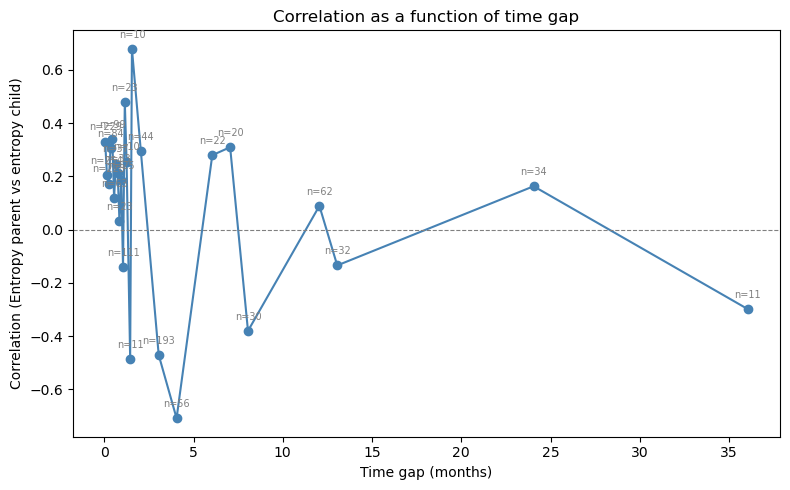

In [30]:
fig = plot_lag_correlation(res, var1_name="Entropy parent", var2_name="entropy child", time_unit="months")
plt.show()

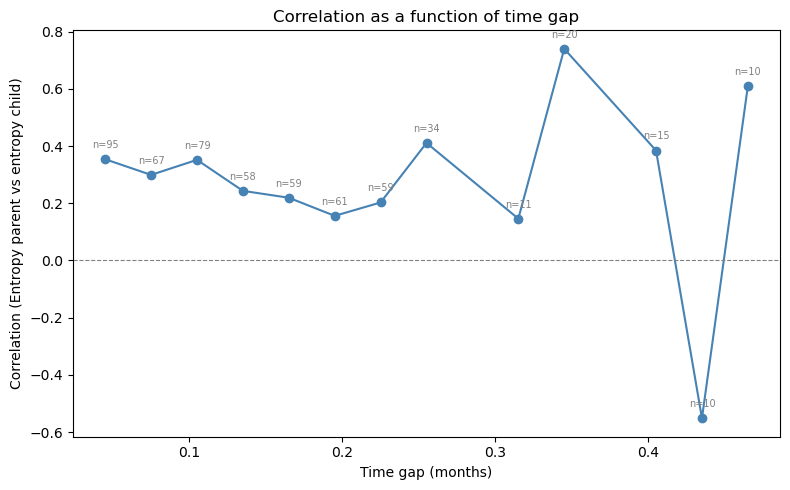

In [44]:
res = binned_lag_correlation(gmm_data2[gmm_data2["name"].isin(['kuczaj_abechi','braunwald_Lchi','brown_sarahchi','macwhinney_rossmarkchi','sachs_naomichi'])], bin_width=0.03)
fig = plot_lag_correlation(res, var1_name="Entropy parent", var2_name="entropy child", time_unit="months")
plt.show()

##### cross correlation for a single participant cod

In [138]:
def plot_single_cross_correlation(par_name="kuczaj_abechi",doplot=True):
    onep = gmm_data2[gmm_data2["name"]==par_name].copy()

    onep_chi = onep.loc[:,["age_months_t2","sum_entropy_child"]]
    onep_par = onep.loc[:,["age_months_t1","sum_entropy_parent"]]

    combined = pd.merge(onep_chi, onep_par, left_on="age_months_t2", right_on="age_months_t1", how="inner")

    combined = combined.set_index(pd.to_timedelta(combined['age_months_t2']*30, unit='D'))

    corr = spc.signal.correlate(combined['sum_entropy_child'], combined['sum_entropy_parent'], mode='full', method='auto')
    corr_norm = corr / np.sqrt(np.sum(np.abs(combined['sum_entropy_child'])**2)*np.sum(np.abs(combined['sum_entropy_child'])**2))
    lags = spc.signal.correlation_lags(len(combined['sum_entropy_child']), len(combined['sum_entropy_parent']), mode='full')

    if doplot:
        plt.figure(figsize=(8, 5))
        plt.plot(lags, corr_norm)
        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.xlabel('Lag (time units)')
        plt.ylabel('Cross-correlation')
        plt.title('Cross-correlation as a function of lag')
        plt.tight_layout()
        plt.show()
    else:
        return corr_norm,lags

def plot_set_of_single_cross_correlation(par_names=['kuczaj_abechi','braunwald_Lchi','brown_sarahchi','macwhinney_rossmarkchi','sachs_naomichi']):
    fig, axes = plt.subplots(1, len(par_names), figsize=(15, 4))

    for ii, par_name in enumerate(par_names):
        corr_norm, lags = plot_single_cross_correlation(par_name=par_name, doplot=False)
        axes[ii].plot(lags, corr_norm)
        axes[ii].set_title(f'Cross-corr for {par_name}')


    plt.tight_layout()
    plt.show()

##### cross correlation for a single participant imple

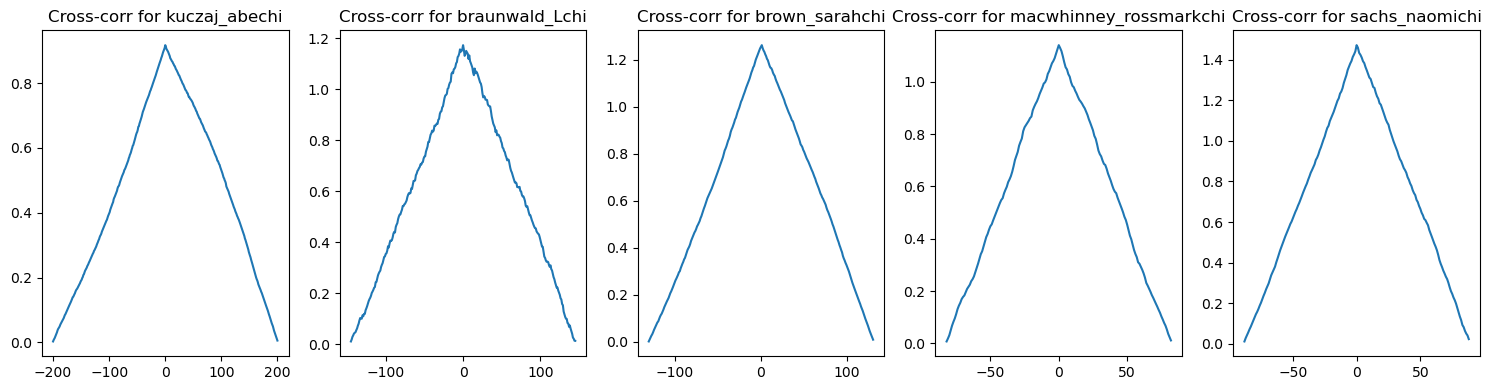

In [139]:
plot_set_of_single_cross_correlation()

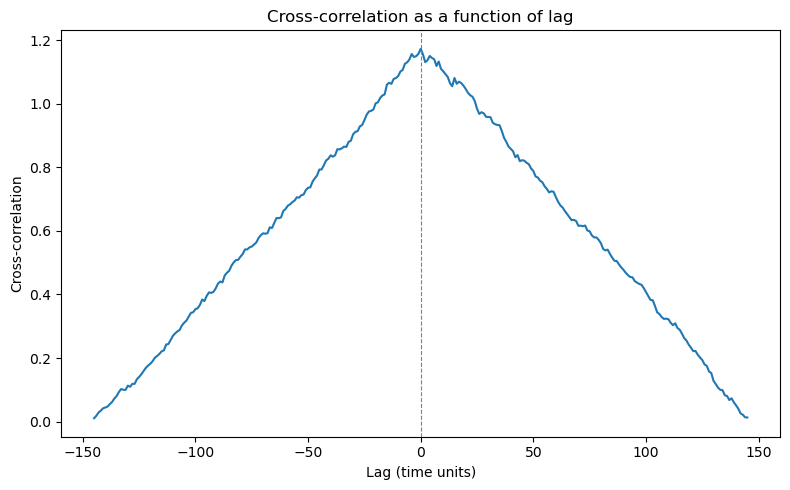

In [123]:
plot_single_cross_correlation(par_name='braunwald_Lchi')

# Stat results
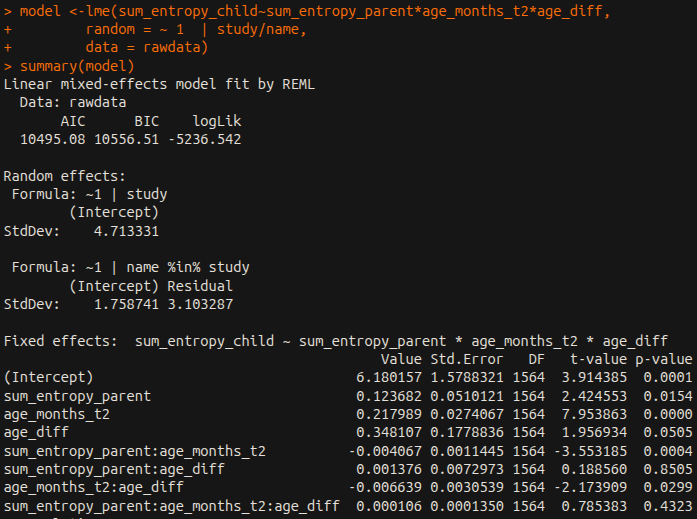
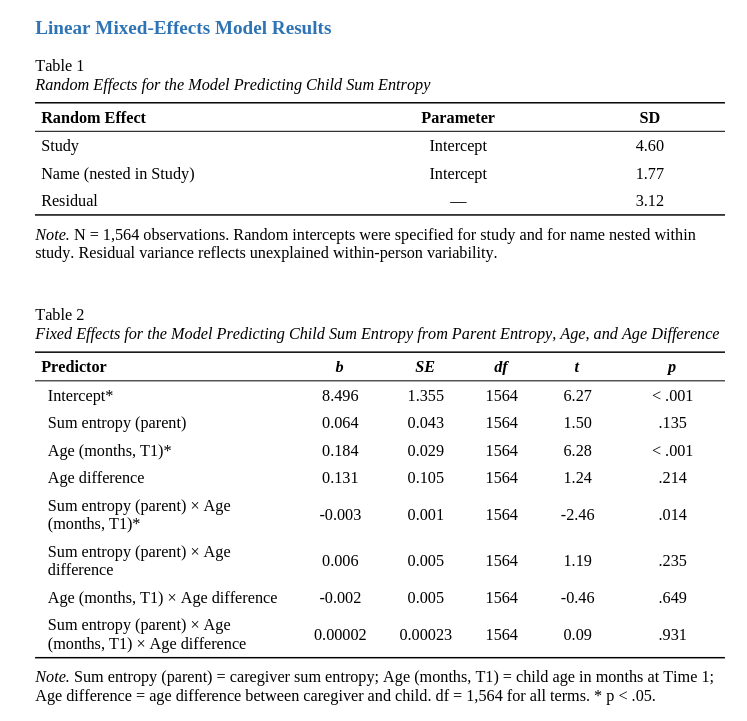
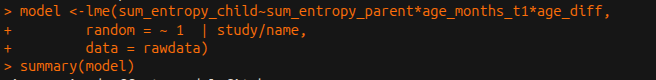

In [140]:
par_name="kuczaj_abechi"
onep = gmm_data2[gmm_data2["name"]==par_name].copy()

onep_chi = onep.loc[:,["age_months_t2","sum_entropy_child"]]
onep_par = onep.loc[:,["age_months_t1","sum_entropy_parent"]]

combined = pd.merge(onep_chi, onep_par, left_on="age_months_t2", right_on="age_months_t1", how="inner")

combined = combined.set_index(pd.to_timedelta(combined['age_months_t2']*30, unit='D'))

In [141]:
combined

,age_months_t2,sum_entropy_child,age_months_t1,sum_entropy_parent
age_months_t2,,,,
870 days 00:00:00,29.000000,17.375,29.000000,26.3125
876 days 23:59:59.999999991,29.233333,17.750,29.233333,20.7500
879 days 23:59:59.999999991,29.333333,15.750,29.333333,20.2500
884 days 00:00:00,29.466667,17.125,29.466667,20.0000
886 days 00:00:00,29.533333,18.375,29.533333,21.7500
...,...,...,...,...
1774 days 23:59:59.999999982,59.166667,24.125,59.166667,23.0000
1783 days 00:00:00,59.433333,27.750,59.433333,21.5000
1791 days 00:00:00,59.700000,22.750,59.700000,19.0000
